# Pattern Recognition 2 - Feature Space

**Objectives**

* Compute distances between objects in feature space
* Use PCA to perform reduce the dimensionality of the problem
* Implement face recognition using [Eigenfaces](http://en.wikipedia.org/wiki/Eigenface)

## Feature space distance

The `ocr_features.npy` file contains extracted features for each letter from the document used in the previous lab, and the `ocr_class.npy` file contains the character corresponding to these features.

The 18 features, extracted with the `regionprops` methods from `scikit-image` are, in order: 

> area, convex area, eccentricity, equivalent diameter, extent, filled area, intertia tensor eigenvalue 1, inertia tensor eigenvalue 2, major axis length, minor axis length, Hu moment 1, Hu moment 2, Hu moment 3, Hu moment 4, Hu moment 5, Hu moment 6, perimeter, solidity

* Create a method which computes the Euclidian distance, in feature space, between two objects.
* Check if the "nearest" object is of the same class.
* What can you do to improve this "distance-based" classification? 

In [107]:
import numpy as np

ocr_features = np.load('../../extern_data/ocr_features.npy')
ocr_class = np.load('../../extern_data/ocr_class.npy')

print(ocr_features.shape)
print(np.unique(ocr_class))

(2392, 18)
['0' '1' '4' '5' 'A' 'B' 'C' 'D' 'F' 'G' 'I' 'L' 'M' 'N' 'O' 'R' 'S' 'T'
 'W' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


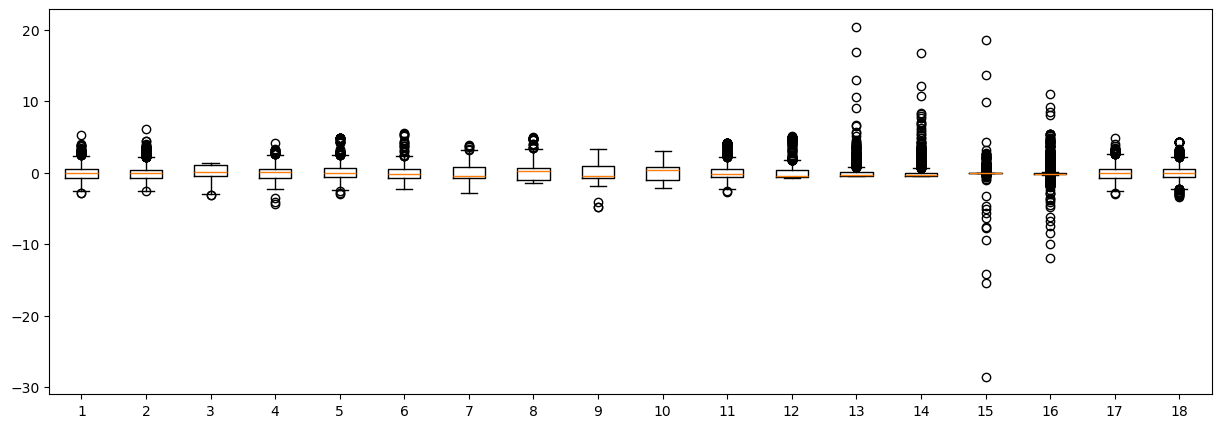

In [108]:
%matplotlib inline
from matplotlib import pyplot as plt

ocr_features = (ocr_features-ocr_features.mean(axis=0))/ocr_features.std(axis=0)

plt.figure(figsize=(15, 5))
plt.boxplot(ocr_features)
plt.show()

In [109]:
## -- Your code here -- ##

def euclidian(A, B):
    return np.sqrt(((A-B)**2).sum())

best_matches = []
for i in range(ocr_features.shape[0]):
    best_match = -1
    best_d = 100000000
    for j in range(ocr_features.shape[0]):
        if i != j: continue
        d = euclidian(ocr_features[i], ocr_features[j])
        if d < best_d:
            best_match = j
            best_d = d
    best_matches.append((i, ocr_class[i], best_match, ocr_class[best_match], best_d))

In [110]:
# Same but faster
best_matches = []
for i in range(ocr_features.shape[0]):
    distances = np.sqrt(((ocr_features-ocr_features[i])**2).sum(axis=1))
    distances[i] = distances.max()
    best_match = distances.argmin()
    best_matches.append((i, ocr_class[i], best_match, ocr_class[best_match], distances.min()))

In [111]:
best_matches = np.array(best_matches)
acc = (best_matches[:, 1] == best_matches[:, 3]).sum()/best_matches.shape[0]
print(acc)

0.9544314381270903


In [112]:
for matches in best_matches:
    if matches[1] != matches[3]:
        print(matches[1], matches[3])

u n
h b
l 1
u n
t i
d b
a e
a e
W R
d b
n u
u n
b d
u n
b d
1 l
b d
u n
I l
d b
R m
u n
n u
M W
a e
0 R
d b
p d
u n
a e
u n
d b
n u
t i
5 f
1 l
n u
u n
n u
p h
t i
5 e
l 1
I f
u n
n u
k h
n u
a s
u n
n u
k d
k h
d b
n u
I l
u n
i t
a e
a e
u n
u n
u n
L f
b h
n u
n u
1 l
n u
a e
n u
u n
1 l
d h
e t
d b
I 1
u n
u n
u n
u n
b d
b d
u n
t o
p d
o t
t e
f t
b h
u n
1 l
n u
u n
q d
F h
p d
b d
a e
D O
d b
a v
b d
u n
a e
a v
s a
a e
e f


## Eigenfaces

The `faces.npy` file contains a 3D matrix containing 2963 images, each with 170x200 pixels, encoded in 8-bit grayscale.

In [113]:
from matplotlib import pyplot as plt
%matplotlib inline

faces = np.load('../../extern_data/faces.npy')
print(faces.shape, faces.dtype, faces.min(), faces.max())

(2963, 200, 170) uint8 0 255


C:\Users\Kevin\AppData\Local\Temp\ipykernel_22420\2914010733.py:4: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  faces = np.load('../../extern_data/faces.npy')


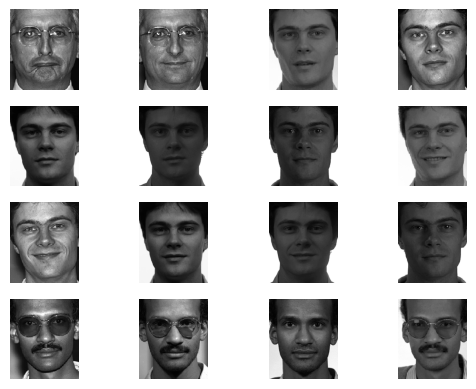

In [114]:
# Show some faces:
plt.figure()
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(faces[i], cmap=plt.cm.gray)
    plt.axis('off')
plt.show()

### Direct approach

1. Write a program that subsample the images (e.g. by 5), converts 2D images into lines, and collect all these lines into one single matrix **T**.
1. Zero-center **T** by removing the "mean image" ($T_i \leftarrow T_i - T_{mean}$)
1. Compute the variance/covariance matrix of **T**:
$$ \mathbf{S} = \mathbf{T^TT}$$
1. Compute the eigenvalues $\lambda_i$ and eigenvectors $\mathbf{v}_i$ of **S**
$$\mathbf{Sv}_i = \mathbf{T^T}\mathbf{Tv}_i = \lambda_i \mathbf{v}_i$$
1. The eigenvectors have the same size as the images, and are often referred to as "eigenfaces". Display some of them.

In [115]:
# Example of eigen value extraction
import numpy as np
from numpy import linalg as LA

w,v = LA.eigh(np.diag((1, 2, 3)))
print(w,v)

[1. 2. 3.] [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


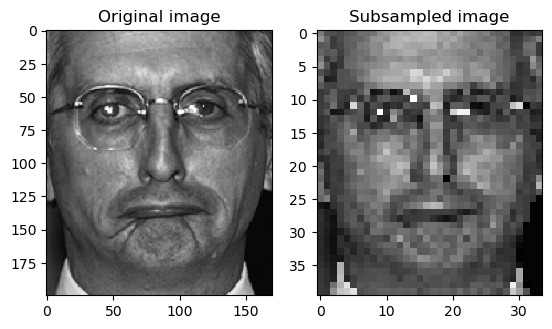

In [116]:
# Example of subsampling
im = faces[0]
plt.figure()
plt.subplot(1,2,1)
plt.imshow(im, cmap=plt.cm.gray)
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(im[::5,::5], cmap=plt.cm.gray)
plt.title("Subsampled image")
plt.show()

(2963, 1360)


(1360,)


<Figure size 640x480 with 0 Axes>

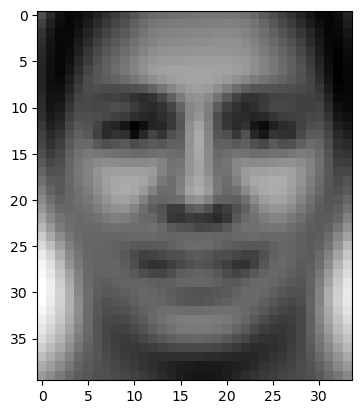

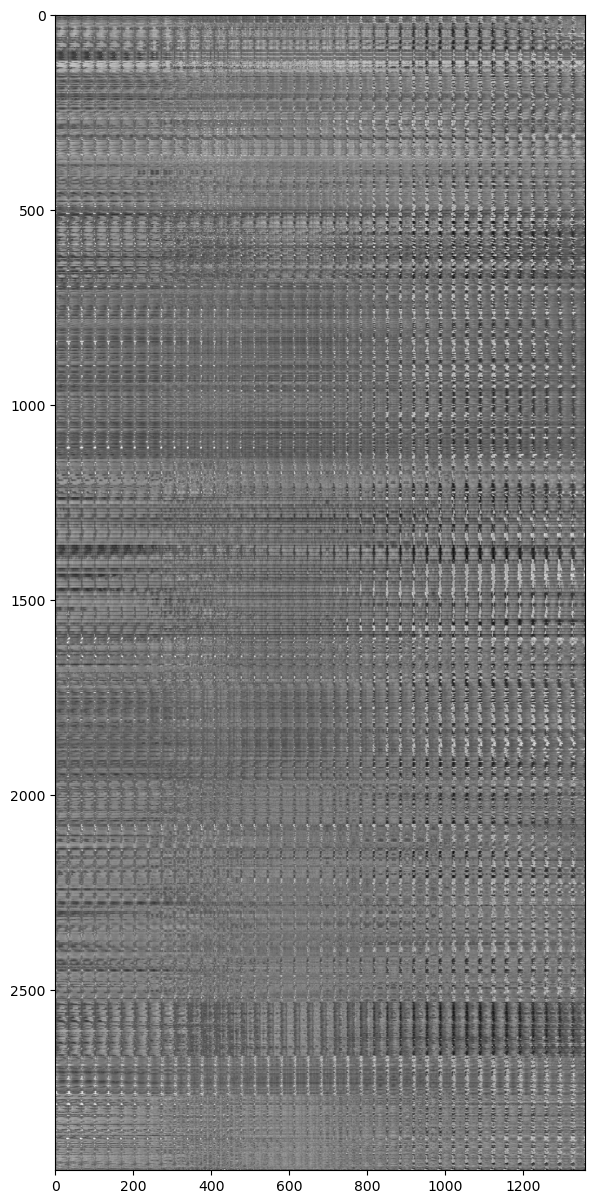

[ 6.53133377e-14  8.69917256e-14 -2.05273230e-14 ...  6.32414209e-14
  4.25798070e-14 -9.09628993e-14]


In [117]:
## -- Your code here -- ##

T = np.array([face[::5,::5].flatten() for face in faces])
print(T.shape)

plt.gray()
im_mean = T.mean(axis=0)
print(im_mean.shape)

T = T-im_mean

plt.figure()
plt.imshow(im_mean.reshape((200//5, 170//5)))
plt.show()

plt.figure(figsize=(10, 15))
plt.imshow(T)
plt.show()

print(T.mean(axis=0))

In [118]:
S = np.dot(T.T, T)
print(S.shape)

(1360, 1360)


In [119]:
w, v = LA.eigh(S)
print(w.shape, v.shape)

(1360,) (1360, 1360)


In [120]:
order = w.argsort()[::-1]
w = w[order]
v = v[:,order]

In [121]:
explained_variance = w/w.sum()
for i in range(len(explained_variance)):
    if explained_variance[:i].sum() > 0.9:
        print(i, explained_variance[:i].sum())
        break
for i in range(len(explained_variance)):
    if explained_variance[:i].sum() > 0.95:
        print(i, explained_variance[:i].sum())
        break

109 0.9004433563654013
248 0.9502026266840315


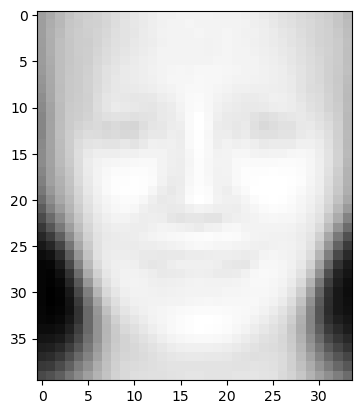

In [122]:
plt.figure()
plt.imshow(v[:,0].reshape((40, 34)))
plt.show()

### Compression

1. Reconstruct images using only the first N eigenfaces (e.g. N=100).
2. Compare (visually) reconstructed images with original images

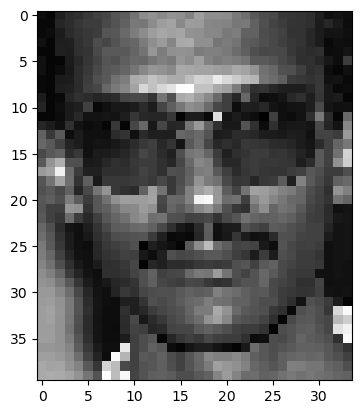

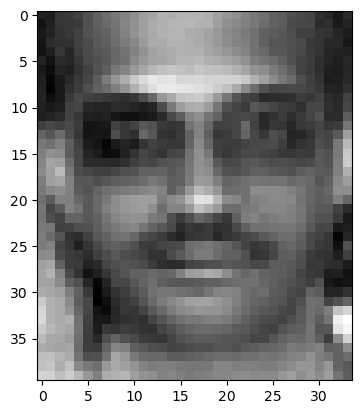

In [123]:
## -- Your code here -- ##

def encode(im, n):
    return np.dot(im, v)[:n]

def decode(encoded, n):
    return np.dot(encoded, (v.T)[:n])

face = T[12]
n = 100
encoded = encode(face, n)
decoded = decode(encoded, n)
plt.figure()
plt.imshow((face+im_mean).reshape((40,34)))
plt.figure()
plt.imshow((decoded+im_mean).reshape((40,34)))
plt.show()


### Face recognition

1. Using the simplified vector space (e.g. 100 first eigenfaces), compute the euclidian distance between one face and the others.
2. For a subset of the image of the database, find the 4 closest matches.

In [124]:
## -- Your code here -- ##

N = 250
T_weights = np.array([encode(face, N) for face in T])
print(T_weights.shape)

(2963, 250)


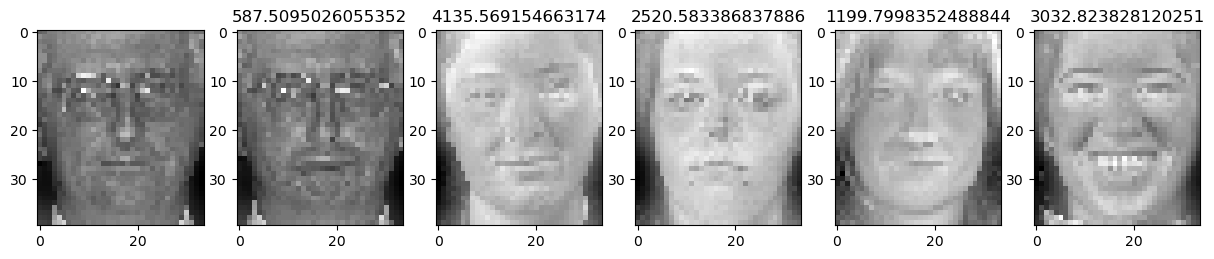

In [125]:
face_id = 1

distances = np.sqrt(((T_weights - T_weights[face_id])**2).sum(axis=1))
distances[face_id] = distances.max()
best_matches = np.argsort(distances)

plt.figure(figsize=(15,5))
plt.subplot(1, 6, 1)
plt.imshow(T[face_id].reshape((40,34)))
for i in range(5):
    plt.subplot(1, 6, i+2)
    plt.imshow(T[best_matches[i]].reshape((40,34)))
    plt.title(distances[i])
plt.show()

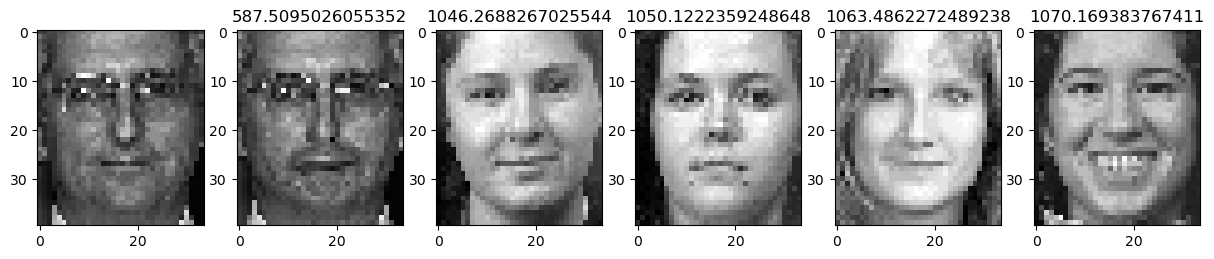

In [126]:
face_id = 1

distances = np.sqrt(((T_weights - T_weights[face_id])**2).sum(axis=1))
distances[face_id] = distances.max()
best_matches = np.argsort(distances)

plt.figure(figsize=(15,5))
plt.subplot(1, 6, 1)
plt.imshow((im_mean+T[face_id]).reshape((40,34)))
for i in range(5):
    plt.subplot(1, 6, i+2)
    plt.imshow((im_mean+T[best_matches[i]]).reshape((40,34)))
    # plt.title(distances[i])
    plt.title(distances[best_matches[i]])
plt.show()

### Indirect approach

Instead of using the eigenvalues/eigenvectors of $\mathbf{S} = \mathbf{T^TT}$, compute the the eigenvalues/eigenvectors of $\mathbf{Q} = \mathbf{TT^T}$.

Let $\mathbf{u_i}$ be the eigenvectors of $\mathbf{Q}$. We have:
$$\mathbf{TT^T}\mathbf{u}_i = \lambda_i \mathbf{u}_i$$

By multiplying to the left with $\mathbf{T^T}$, we have:
$$\mathbf{T^T}\mathbf{TT^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$
$$\mathbf{S}\mathbf{T^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$

Which means that if $\mathbf{u}_i$ is eigenvector of $\mathbf{Q}$, then $\mathbf{T^T}\mathbf{u}_i$ is eigenvector of $\mathbf{S}$.

The indirect approach thus becomes:
1. Compute the eigenvectors $\mathbf{u}_i$ of $\mathbf{Q} = \mathbf{TT^T}$.
1. Compute the eigenfaces with $\mathbf{v}_i = \mathbf{T^T}\mathbf{u}_i$ 
1. Reconstruct the images using only the first N eigenfaces (e.g. N=100)
1. Compare (visually) reconstructed images with original images
1. Use the indirect approach with more resolution (without subsampling the images)

Use this new feature space to perform the same face recognition method.

In [127]:
## -- Your code here -- ##

# Indirect approach, step 1 & 2: instead of diagonalizing
# S = T^T T  (1360 x 1360), diagonalize Q = T T^T (2963 x 2963).
# Q is symmetric, so use eigh (real eigenvalues/eigenvectors,
# avoids the complex128 issue that broke the plots above).

Q = np.dot(T, T.T)
print("Q shape:", Q.shape)

w_q, u = LA.eigh(Q)

# Sort eigenvalues/eigenvectors in descending order
order = w_q.argsort()[::-1]
w_q = w_q[order]
u = u[:, order]

# Eigenfaces: v_i = T^T u_i, normalized to unit length
v_indirect = np.dot(T.T, u)
v_indirect = v_indirect / np.linalg.norm(v_indirect, axis=0)

print("v_indirect shape:", v_indirect.shape)

# Sanity check: the non-zero eigenvalues of Q and S should match
print("Top eigenvalues match S:", np.allclose(w_q[:10], w[:10]))

Q shape: (2963, 2963)
v_indirect shape: (1360, 2963)
Top eigenvalues match S: True


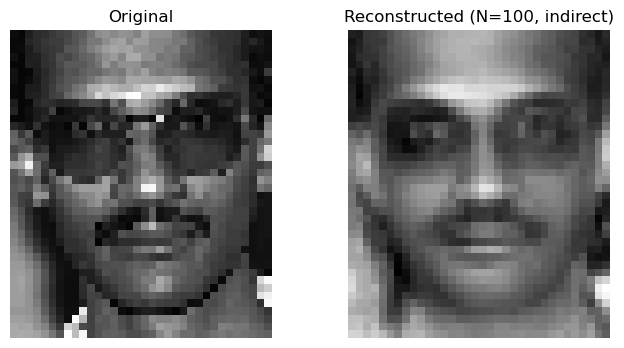

In [128]:
# Indirect approach, step 3 & 4: reconstruct using the first N
# eigenfaces obtained from Q, and compare with the original image.

def encode_indirect(im, n):
    return np.dot(im, v_indirect)[:n]

def decode_indirect(encoded, n):
    return np.dot(encoded, (v_indirect.T)[:n])

face = T[12]
n = 100
encoded = encode_indirect(face, n)
decoded = decode_indirect(encoded, n)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow((face + im_mean).reshape((40, 34)))
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow((decoded + im_mean).reshape((40, 34)))
plt.title(f"Reconstructed (N={n}, indirect)")
plt.axis('off')
plt.show()

T_full shape: (2963, 34000)
Q_full shape: (2963, 2963)
v_full shape: (34000, 300)


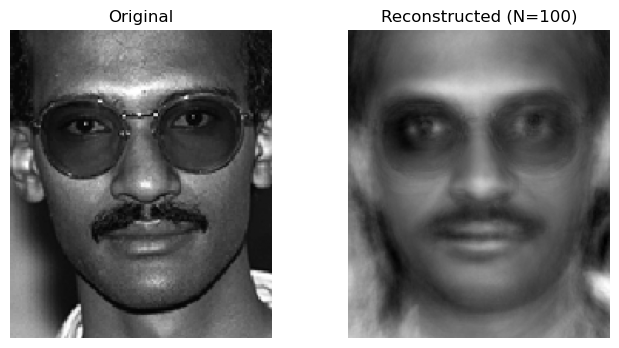

In [129]:
# Indirect approach, step 5: redo without subsampling (full resolution).
#
# At full resolution each image has 200*170 = 34000 pixels, so
# S = T^T T would be 34000 x 34000 -- far too large to diagonalize
# directly. Q = T T^T is still only 2963 x 2963 (one entry per pair
# of images), so the indirect approach is the only practical option
# here.

T_full = np.array([face.flatten() for face in faces]).astype(np.float64)
print("T_full shape:", T_full.shape)

im_mean_full = T_full.mean(axis=0)
T_full = T_full - im_mean_full

Q_full = np.dot(T_full, T_full.T)
print("Q_full shape:", Q_full.shape)

w_full, u_full = LA.eigh(Q_full)

order = w_full.argsort()[::-1]
w_full = w_full[order]
u_full = u_full[:, order]

# Only compute as many eigenfaces as we'll actually use (T^T u_full is
# the expensive 34000 x 2963 x N matrix product), 300 is enough for
# both the reconstruction and the face-recognition step below.
N_MAX = 300
v_full = np.dot(T_full.T, u_full[:, :N_MAX])
v_full = v_full / np.linalg.norm(v_full, axis=0)
print("v_full shape:", v_full.shape)


def encode_full(im, n):
    return np.dot(im, v_full)[:n]


def decode_full(encoded, n):
    return np.dot(encoded, (v_full.T)[:n])


# Compare original vs. reconstruction at full resolution
face_id = 12
n = 100
face = T_full[face_id]
decoded = decode_full(encode_full(face, n), n)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow((face + im_mean_full).reshape((200, 170)), cmap=plt.cm.gray)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow((decoded + im_mean_full).reshape((200, 170)), cmap=plt.cm.gray)
plt.title(f"Reconstructed (N={n})")
plt.axis('off')
plt.show()

T_weights_full shape: (2963, 250)


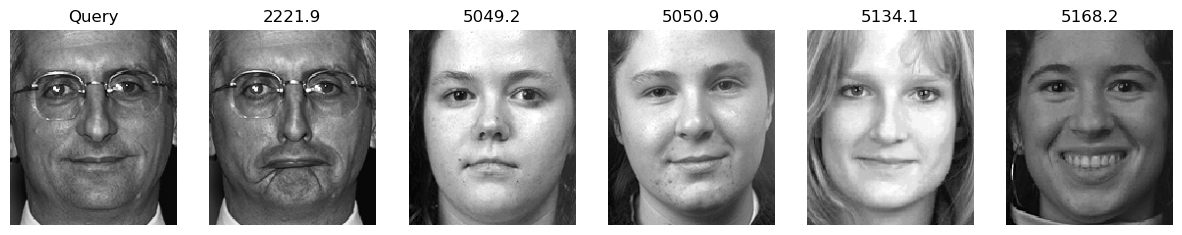

In [130]:
# Face recognition using the new (full-resolution, indirect) feature space.

N = 250
T_weights_full = np.dot(T_full, v_full[:, :N])
print("T_weights_full shape:", T_weights_full.shape)

face_id = 1
distances = np.sqrt(((T_weights_full - T_weights_full[face_id]) ** 2).sum(axis=1))
distances[face_id] = distances.max()
best_matches = np.argsort(distances)

plt.figure(figsize=(15, 5))
plt.subplot(1, 6, 1)
plt.imshow((T_full[face_id] + im_mean_full).reshape((200, 170)), cmap=plt.cm.gray)
plt.title("Query")
plt.axis('off')

for i in range(5):
    idx = best_matches[i]
    plt.subplot(1, 6, i + 2)
    plt.imshow((T_full[idx] + im_mean_full).reshape((200, 170)), cmap=plt.cm.gray)
    plt.title(f"{distances[idx]:.1f}")
    plt.axis('off')

plt.show()